# Haz waste Detection

In [1]:
## Importing the Libraries

import os
import shutil
import random
from pathlib import Path
from collections import defaultdict

import yaml
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [2]:
def create_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def reset_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def get_image_files(images_dir: Path):
    if not images_dir.exists():
        return []
    return [f for f in images_dir.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTS]

def copy_image_and_label(image_path: Path, label_path: Path, dst_images_dir: Path, dst_labels_dir: Path, new_stem: str):
    new_image_path = dst_images_dir / f"{new_stem}{image_path.suffix.lower()}"
    new_label_path = dst_labels_dir / f"{new_stem}.txt"

    shutil.copy2(image_path, new_image_path)
    shutil.copy2(label_path, new_label_path)

def collect_from_split(dataset_dir: Path, dataset_tag: str, split_name: str, dst_images_dir: Path, dst_labels_dir: Path):
    split_dir = dataset_dir / split_name
    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"

    if not images_dir.exists() or not labels_dir.exists():
        print(f"[WARNING] Missing {split_name} folder in {dataset_dir.name}. Skipping.")
        return 0, 0

    image_files = get_image_files(images_dir)
    copied_count = 0
    missing_labels = 0

    print(f"\nCollecting from {dataset_dir.name}/{split_name} ...")

    for idx, image_path in enumerate(tqdm(image_files, desc=f"{dataset_tag}_{split_name}")):
        label_path = labels_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            missing_labels += 1
            continue

        new_stem = f"{dataset_tag}_{split_name}_{idx:05d}"
        copy_image_and_label(
            image_path=image_path,
            label_path=label_path,
            dst_images_dir=dst_images_dir,
            dst_labels_dir=dst_labels_dir,
            new_stem=new_stem
        )
        copied_count += 1

    return copied_count, missing_labels

def parse_label_classes(label_file: Path):
    classes = []
    with open(label_file, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                try:
                    cls_id = int(parts[0])
                    classes.append(cls_id)
                except ValueError:
                    continue
    return classes

def get_all_merged_pairs(images_dir: Path, labels_dir: Path):
    pairs = []
    for image_path in get_image_files(images_dir):
        label_path = labels_dir / f"{image_path.stem}.txt"
        if label_path.exists():
            pairs.append((image_path, label_path))
    return pairs

def summarize_class_distribution(label_files):
    class_counts = defaultdict(int)
    image_presence_counts = defaultdict(int)

    for label_file in label_files:
        classes_in_image = parse_label_classes(label_file)
        seen = set()

        for cls_id in classes_in_image:
            class_counts[cls_id] += 1
            seen.add(cls_id)

        for cls_id in seen:
            image_presence_counts[cls_id] += 1

    return class_counts, image_presence_counts

In [3]:

# 1. CONFIG

BASE_DIR = Path.cwd()

DATASETS_DIR = BASE_DIR / "datasets"
V1_DIR = DATASETS_DIR / "V1"
V2_DIR = DATASETS_DIR / "V2"

MERGED_RAW_DIR = DATASETS_DIR / "merged_raw"
FINAL_DATASET_DIR = DATASETS_DIR / "final_dataset"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

CLASS_NAMES = ["Cylinder", "Shock_Absorber"]
NUM_CLASSES = len(CLASS_NAMES)

TRAIN_RATIO = 0.80
VALID_RATIO = 0.10
TEST_RATIO = 0.10
RANDOM_STATE = 42

print("=" * 80)
print("PROJECT PATH CHECK")
print("=" * 80)
print("BASE_DIR         :", BASE_DIR)
print("DATASETS_DIR     :", DATASETS_DIR)
print("V1_DIR exists?   :", V1_DIR.exists(), "->", V1_DIR)
print("V2_DIR exists?   :", V2_DIR.exists(), "->", V2_DIR)
print("MERGED_RAW_DIR   :", MERGED_RAW_DIR)
print("FINAL_DATASET_DIR:", FINAL_DATASET_DIR)

if not V1_DIR.exists():
    raise FileNotFoundError(f"V1 dataset folder not found: {V1_DIR}")

if not V2_DIR.exists():
    raise FileNotFoundError(f"V2 dataset folder not found: {V2_DIR}")

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================
def create_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def reset_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def get_image_files(images_dir: Path):
    if not images_dir.exists():
        return []
    return [f for f in images_dir.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTS]

def copy_image_and_label(image_path: Path, label_path: Path, dst_images_dir: Path, dst_labels_dir: Path, new_stem: str):
    new_image_path = dst_images_dir / f"{new_stem}{image_path.suffix.lower()}"
    new_label_path = dst_labels_dir / f"{new_stem}.txt"

    shutil.copy2(image_path, new_image_path)
    shutil.copy2(label_path, new_label_path)

def collect_from_split(dataset_dir: Path, dataset_tag: str, split_name: str, dst_images_dir: Path, dst_labels_dir: Path):
    split_dir = dataset_dir / split_name
    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"

    if not images_dir.exists() or not labels_dir.exists():
        print(f"[WARNING] Missing {split_name} folder in {dataset_dir.name}. Skipping.")
        return 0, 0

    image_files = get_image_files(images_dir)
    copied_count = 0
    missing_labels = 0

    print(f"\nCollecting from {dataset_dir.name}/{split_name} ...")
    print(f"Images found: {len(image_files)}")

    for idx, image_path in enumerate(tqdm(image_files, desc=f"{dataset_tag}_{split_name}")):
        label_path = labels_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            missing_labels += 1
            continue

        new_stem = f"{dataset_tag}_{split_name}_{idx:05d}"
        copy_image_and_label(
            image_path=image_path,
            label_path=label_path,
            dst_images_dir=dst_images_dir,
            dst_labels_dir=dst_labels_dir,
            new_stem=new_stem
        )
        copied_count += 1

    return copied_count, missing_labels

def parse_label_classes(label_file: Path):
    classes = []
    with open(label_file, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                try:
                    cls_id = int(parts[0])
                    classes.append(cls_id)
                except ValueError:
                    continue
    return classes

def get_all_merged_pairs(images_dir: Path, labels_dir: Path):
    pairs = []
    for image_path in get_image_files(images_dir):
        label_path = labels_dir / f"{image_path.stem}.txt"
        if label_path.exists():
            pairs.append((image_path, label_path))
    return pairs

def summarize_class_distribution(label_files):
    class_counts = defaultdict(int)
    image_presence_counts = defaultdict(int)

    for label_file in label_files:
        classes_in_image = parse_label_classes(label_file)
        seen = set()

        for cls_id in classes_in_image:
            class_counts[cls_id] += 1
            seen.add(cls_id)

        for cls_id in seen:
            image_presence_counts[cls_id] += 1

    return class_counts, image_presence_counts

def copy_pairs_to_split(pairs, split_name, final_dataset_dir: Path):
    split_images_dir = final_dataset_dir / split_name / "images"
    split_labels_dir = final_dataset_dir / split_name / "labels"

    create_dir(split_images_dir)
    create_dir(split_labels_dir)

    for image_path, label_path in tqdm(pairs, desc=f"Copying to {split_name}"):
        shutil.copy2(image_path, split_images_dir / image_path.name)
        shutil.copy2(label_path, split_labels_dir / label_path.name)

# ============================================================
# 3. CREATE merged_raw
# ============================================================
print("\n" + "=" * 80)
print("STEP 1: MERGING V1 + V2 INTO merged_raw")
print("=" * 80)

merged_images_dir = MERGED_RAW_DIR / "images"
merged_labels_dir = MERGED_RAW_DIR / "labels"

reset_dir(MERGED_RAW_DIR)
create_dir(merged_images_dir)
create_dir(merged_labels_dir)

total_copied = 0
total_missing = 0

datasets_to_collect = [
    (V1_DIR, "v1"),
    (V2_DIR, "v2"),
]

for dataset_dir, tag in datasets_to_collect:
    for split_name in ["train", "valid"]:
        copied, missing = collect_from_split(
            dataset_dir=dataset_dir,
            dataset_tag=tag,
            split_name=split_name,
            dst_images_dir=merged_images_dir,
            dst_labels_dir=merged_labels_dir
        )
        total_copied += copied
        total_missing += missing

print("\n===== MERGE SUMMARY =====")
print("Total copied image-label pairs :", total_copied)
print("Missing labels skipped         :", total_missing)

# ============================================================
# 4. CHECK merged total
# ============================================================
print("\n" + "=" * 80)
print("STEP 2: CHECKING MERGED DATA")
print("=" * 80)

all_pairs = get_all_merged_pairs(merged_images_dir, merged_labels_dir)
total_merged_pairs = len(all_pairs)

print("Total merged usable pairs:", total_merged_pairs)

if total_merged_pairs == 0:
    raise ValueError("No valid image-label pairs found. Check dataset paths and folder structure.")

# ============================================================
# 5. SPLIT train / valid / test
# ============================================================
print("\n" + "=" * 80)
print("STEP 3: SPLITTING INTO TRAIN / VALID / TEST")
print("=" * 80)

random.seed(RANDOM_STATE)
random.shuffle(all_pairs)

train_pairs, temp_pairs = train_test_split(
    all_pairs,
    test_size=(1 - TRAIN_RATIO),
    random_state=RANDOM_STATE,
    shuffle=True
)

valid_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=RANDOM_STATE,
    shuffle=True
)

print("Train:", len(train_pairs))
print("Valid:", len(valid_pairs))
print("Test :", len(test_pairs))

# sanity check
if len(train_pairs) + len(valid_pairs) + len(test_pairs) != total_merged_pairs:
    raise ValueError("Split counts do not add up to total merged pairs.")

# ============================================================
# 6. CREATE final_dataset
# ============================================================
print("\n" + "=" * 80)
print("STEP 4: CREATING final_dataset")
print("=" * 80)

reset_dir(FINAL_DATASET_DIR)

copy_pairs_to_split(train_pairs, "train", FINAL_DATASET_DIR)
copy_pairs_to_split(valid_pairs, "valid", FINAL_DATASET_DIR)
copy_pairs_to_split(test_pairs, "test", FINAL_DATASET_DIR)

print("Final split dataset created at:", FINAL_DATASET_DIR)

# ============================================================
# 7. CREATE data.yaml
# ============================================================
print("\n" + "=" * 80)
print("STEP 5: WRITING data.yaml")
print("=" * 80)

data_yaml = {
    "train": str((FINAL_DATASET_DIR / "train" / "images").as_posix()),
    "val": str((FINAL_DATASET_DIR / "valid" / "images").as_posix()),
    "test": str((FINAL_DATASET_DIR / "test" / "images").as_posix()),
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES
}

yaml_path = FINAL_DATASET_DIR / "data.yaml"

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("data.yaml created at:", yaml_path)
print(data_yaml)

# ============================================================
# 8. CLASS DISTRIBUTION SUMMARY
# ============================================================
print("\n" + "=" * 80)
print("STEP 6: CLASS DISTRIBUTION SUMMARY")
print("=" * 80)

summary_rows = []

for split_name in ["train", "valid", "test"]:
    split_labels_dir = FINAL_DATASET_DIR / split_name / "labels"
    label_files = list(split_labels_dir.glob("*.txt"))

    class_counts, image_presence_counts = summarize_class_distribution(label_files)

    print(f"\n===== {split_name.upper()} =====")
    print(f"Total label files: {len(label_files)}")

    for cls_id, cls_name in enumerate(CLASS_NAMES):
        obj_count = class_counts.get(cls_id, 0)
        img_count = image_presence_counts.get(cls_id, 0)

        print(f"Class {cls_id} - {cls_name}")
        print(f"  Object annotations      : {obj_count}")
        print(f"  Images containing class : {img_count}")

        summary_rows.append({
            "split": split_name,
            "class_id": cls_id,
            "class_name": cls_name,
            "object_annotations": obj_count,
            "images_containing_class": img_count
        })

summary_df = pd.DataFrame(summary_rows)

print("\n" + "=" * 80)
print("FINAL SUMMARY TABLE")
print("=" * 80)
display(summary_df)

print("\n" + "=" * 80)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 80)
print("merged_raw folder   :", MERGED_RAW_DIR)
print("final_dataset folder:", FINAL_DATASET_DIR)
print("Use this YAML for training:", yaml_path)

PROJECT PATH CHECK
BASE_DIR         : c:\HAZ
DATASETS_DIR     : c:\HAZ\datasets
V1_DIR exists?   : True -> c:\HAZ\datasets\V1
V2_DIR exists?   : True -> c:\HAZ\datasets\V2
MERGED_RAW_DIR   : c:\HAZ\datasets\merged_raw
FINAL_DATASET_DIR: c:\HAZ\datasets\final_dataset

STEP 1: MERGING V1 + V2 INTO merged_raw

Images found: 294


v1_train: 100%|██████████| 294/294 [00:04<00:00, 71.47it/s]



Images found: 2


v1_valid: 100%|██████████| 2/2 [00:00<00:00, 82.58it/s]



Images found: 294


...


===== MERGE SUMMARY =====
Total copied image-label pairs : 592
Missing labels skipped         : 0

STEP 2: CHECKING MERGED DATA
Total merged usable pairs: 592

STEP 3: SPLITTING INTO TRAIN / VALID / TEST
Train: 473
Valid: 59
Test : 60

STEP 4: CREATING final_dataset


Copying to test: 100%|██████████| 60/60 [00:00<00:00, 97.55it/s]


Final split dataset created at: c:\HAZ\datasets\final_dataset

STEP 5: WRITING data.yaml
data.yaml created at: c:\HAZ\datasets\final_dataset\data.yaml
{'train': 'c:/HAZ/datasets/final_dataset/train/images', 'val': 'c:/HAZ/datasets/final_dataset/valid/images', 'test': 'c:/HAZ/datasets/final_dataset/test/images', 'nc': 2, 'names': ['Cylinder', 'Shock_Absorber']}

STEP 6: CLASS DISTRIBUTION SUMMARY

===== TRAIN =====
Total label files: 473
Class 0 - Cylinder
  Object annotations      : 609
  Images containing class : 411
Class 1 - Shock_Absorber
  Object annotations      : 173
  Images containing class : 74

===== VALID =====
Total label files: 59
Class 0 - Cylinder
  Object annotations      : 68
  Images containing class : 48
Class 1 - Shock_Absorber
  Object annotations      : 28
  Images containing class : 14

===== TEST =====
Total label files: 60
Class 0 - Cylinder
  Object annotations      : 79
  Images containing class : 55
Class 1 - Shock_Absorber
  Object annotations      : 15
  

,split,class_id,class_name,object_annotations,images_containing_class
0,train,0,Cylinder,609,411
1,train,1,Shock_Absorber,173,74
2,valid,0,Cylinder,68,48
3,valid,1,Shock_Absorber,28,14
4,test,0,Cylinder,79,55
5,test,1,Shock_Absorber,15,8



PIPELINE COMPLETED SUCCESSFULLY
merged_raw folder   : c:\HAZ\datasets\merged_raw
final_dataset folder: c:\HAZ\datasets\final_dataset
Use this YAML for training: c:\HAZ\datasets\final_dataset\data.yaml


DATASET AUDIT - PATH CHECK
BASE_DIR          : c:\HAZ
FINAL_DATASET_DIR : c:\HAZ\datasets\final_dataset
Dataset exists?   : True

STARTING DATASET AUDIT

[TRAIN] Images found: 473

[VALID] Images found: 59

[TEST] Images found: 60

AUDIT SUMMARY

Split-level summary:


,split,num_images,missing_labels,empty_labels,invalid_labels,corrupted_images,images_with_both_classes,Cylinder_object_annotations,Cylinder_images_present,Shock_Absorber_object_annotations,Shock_Absorber_images_present
0,train,473,0,0,473,0,0,0,0,0,0
1,valid,59,0,0,59,0,0,0,0,0,0
2,test,60,0,0,60,0,0,0,0,0,0



Overall counts:
Total audited images           : 592
Total issue records            : 972
Total duplicate image entries  : 268

Issue breakdown:


,count
issue,
invalid_column_count_line_1,592
invalid_column_count_line_2,278
invalid_column_count_line_3,72
invalid_column_count_line_4,18
invalid_column_count_line_5,6
invalid_column_count_line_6,6



Duplicate image groups found:
Unique duplicate hash groups: 103


,hash,split,file_name,file_path,duplicate_group_size
215,05c0c3ebbd3910dcc8c96ac955914e4a,train,v1_train_00272.jpg,c:\HAZ\datasets\final_dataset\train\images\v1_...,3
216,05c0c3ebbd3910dcc8c96ac955914e4a,train,v2_train_00270.jpg,c:\HAZ\datasets\final_dataset\train\images\v2_...,3
217,05c0c3ebbd3910dcc8c96ac955914e4a,valid,v1_train_00270.jpg,c:\HAZ\datasets\final_dataset\valid\images\v1_...,3
76,05ddb5094c62c00033a7e950588ae438,test,v1_train_00087.jpg,c:\HAZ\datasets\final_dataset\test\images\v1_t...,4
73,05ddb5094c62c00033a7e950588ae438,train,v1_train_00088.jpg,c:\HAZ\datasets\final_dataset\train\images\v1_...,4
74,05ddb5094c62c00033a7e950588ae438,train,v1_train_00089.jpg,c:\HAZ\datasets\final_dataset\train\images\v1_...,4
75,05ddb5094c62c00033a7e950588ae438,train,v2_train_00088.jpg,c:\HAZ\datasets\final_dataset\train\images\v2_...,4
16,0d36c70493a056544d284131cad55bdd,train,v1_train_00020.jpg,c:\HAZ\datasets\final_dataset\train\images\v1_...,2
17,0d36c70493a056544d284131cad55bdd,train,v2_train_00020.jpg,c:\HAZ\datasets\final_dataset\train\images\v2_...,2
67,0df48918c3f80add62bbcbc5f5edd3fc,train,v1_train_00082.jpg,c:\HAZ\datasets\final_dataset\train\images\v1_...,3



EXTRA ANALYSIS
Images with zero parsed objects: 592
Images containing both classes : 0

Image dimension summary:


,width,height
count,592.0,592.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0


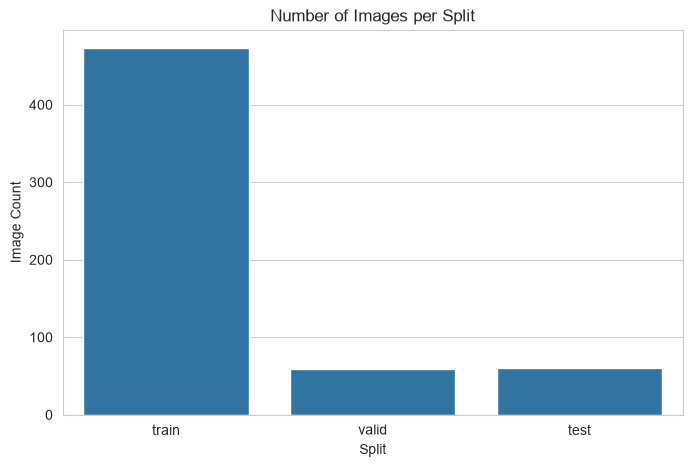

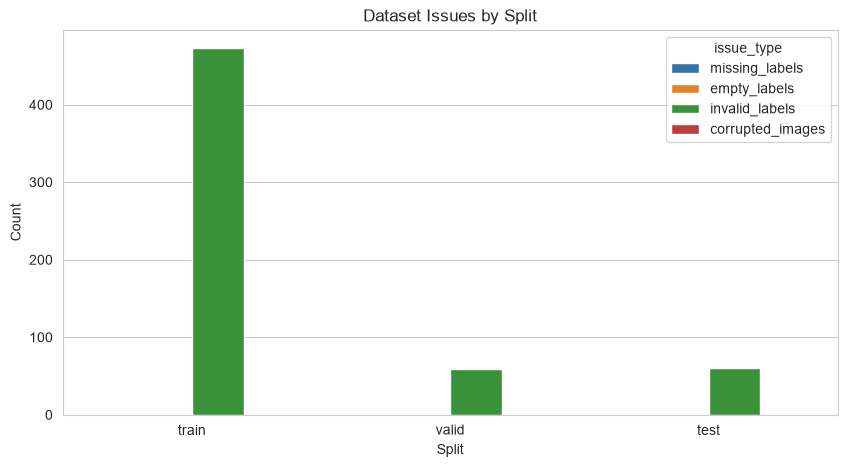

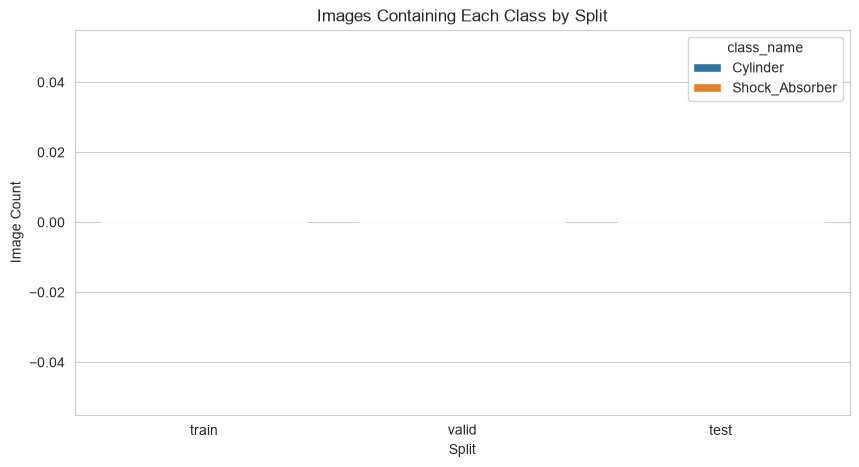

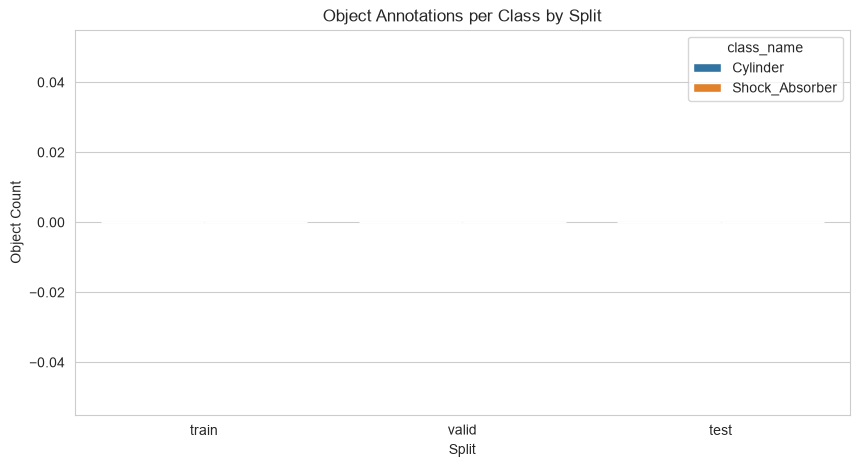


AUDIT REPORT FILES SAVED
Saved to: c:\HAZ\datasets\final_dataset\audit_reports
- audit_full_image_report.csv
- audit_issues_report.csv
- audit_duplicate_images_report.csv
- audit_split_summary.csv

DATASET AUDIT COMPLETED


In [4]:
# ============================================================
# HAZWASTE DATASET QUALITY AUDIT (ONE-CELL VERSION)
# ============================================================

import os
import cv2
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import defaultdict, Counter

warnings.filterwarnings("ignore")

# ============================================================
# 1. CONFIG
# ============================================================
BASE_DIR = Path.cwd()
FINAL_DATASET_DIR = BASE_DIR / "datasets" / "final_dataset"

CLASS_NAMES = ["Cylinder", "Shock_Absorber"]
NUM_CLASSES = len(CLASS_NAMES)
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("=" * 90)
print("DATASET AUDIT - PATH CHECK")
print("=" * 90)
print("BASE_DIR          :", BASE_DIR)
print("FINAL_DATASET_DIR :", FINAL_DATASET_DIR)
print("Dataset exists?   :", FINAL_DATASET_DIR.exists())

if not FINAL_DATASET_DIR.exists():
    raise FileNotFoundError(f"final_dataset not found at: {FINAL_DATASET_DIR}")

# ============================================================
# 2. HELPERS
# ============================================================
def get_image_files(images_dir: Path):
    if not images_dir.exists():
        return []
    return [f for f in images_dir.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTS]

def md5_hash(file_path: Path, chunk_size=8192):
    h = hashlib.md5()
    with open(file_path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def read_label_file(label_path: Path):
    """
    Returns:
        rows: list of parsed YOLO rows
        issues: list of issues found in this label file
    YOLO row format:
        class x_center y_center width height
    """
    rows = []
    issues = []

    if not label_path.exists():
        issues.append("missing_label_file")
        return rows, issues

    text = label_path.read_text(encoding="utf-8").strip()

    if text == "":
        issues.append("empty_label_file")
        return rows, issues

    lines = text.splitlines()

    for line_num, line in enumerate(lines, start=1):
        parts = line.strip().split()

        if len(parts) != 5:
            issues.append(f"invalid_column_count_line_{line_num}")
            continue

        # Parse class id
        try:
            cls_id = int(parts[0])
        except:
            issues.append(f"invalid_class_id_line_{line_num}")
            continue

        # Parse bbox values
        try:
            x, y, w, h = map(float, parts[1:])
        except:
            issues.append(f"invalid_bbox_values_line_{line_num}")
            continue

        # Check class range
        if cls_id < 0 or cls_id >= NUM_CLASSES:
            issues.append(f"class_id_out_of_range_line_{line_num}")

        # YOLO normalized values should be between 0 and 1
        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
            issues.append(f"bbox_out_of_range_line_{line_num}")

        rows.append([cls_id, x, y, w, h])

    return rows, issues

def inspect_image(image_path: Path):
    """
    Returns:
        readable (bool), width, height, channels
    """
    try:
        img = cv2.imread(str(image_path))
        if img is None:
            return False, None, None, None

        h, w = img.shape[:2]
        c = img.shape[2] if len(img.shape) == 3 else 1
        return True, w, h, c
    except:
        return False, None, None, None

# ============================================================
# 3. AUDIT CONTAINERS
# ============================================================
audit_rows = []
issue_rows = []
duplicate_rows = []

global_hash_map = defaultdict(list)

split_summary = []

# ============================================================
# 4. MAIN AUDIT LOOP
# ============================================================
print("\n" + "=" * 90)
print("STARTING DATASET AUDIT")
print("=" * 90)

for split_name in ["train", "valid", "test"]:
    split_dir = FINAL_DATASET_DIR / split_name
    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"

    if not images_dir.exists():
        print(f"[WARNING] Missing images dir for split: {split_name}")
        continue

    if not labels_dir.exists():
        print(f"[WARNING] Missing labels dir for split: {split_name}")
        continue

    image_files = get_image_files(images_dir)
    print(f"\n[{split_name.upper()}] Images found: {len(image_files)}")

    split_object_counter = Counter()
    split_image_presence_counter = Counter()
    split_both_classes_count = 0
    split_empty_labels = 0
    split_missing_labels = 0
    split_corrupted_images = 0
    split_invalid_labels = 0

    for image_path in image_files:
        label_path = labels_dir / f"{image_path.stem}.txt"

        # ---- image inspection ----
        readable, width, height, channels = inspect_image(image_path)
        if not readable:
            split_corrupted_images += 1
            issue_rows.append({
                "split": split_name,
                "file_type": "image",
                "file_name": image_path.name,
                "issue": "corrupted_or_unreadable_image"
            })

        # ---- duplicate detection by hash ----
        try:
            file_hash = md5_hash(image_path)
            global_hash_map[file_hash].append((split_name, image_path.name, str(image_path)))
        except Exception as e:
            file_hash = None
            issue_rows.append({
                "split": split_name,
                "file_type": "image",
                "file_name": image_path.name,
                "issue": f"hash_error: {str(e)}"
            })

        # ---- label inspection ----
        rows, issues = read_label_file(label_path)

        if not label_path.exists():
            split_missing_labels += 1

        if "empty_label_file" in issues:
            split_empty_labels += 1

        # if any issue other than empty/missing exists, count as invalid label
        non_trivial_issues = [
            x for x in issues if x not in {"missing_label_file", "empty_label_file"}
        ]
        if len(non_trivial_issues) > 0:
            split_invalid_labels += 1

        for issue in issues:
            issue_rows.append({
                "split": split_name,
                "file_type": "label",
                "file_name": label_path.name,
                "issue": issue
            })

        # ---- class stats from valid parsed rows ----
        classes_in_image = set()

        for row in rows:
            cls_id = row[0]
            split_object_counter[cls_id] += 1
            classes_in_image.add(cls_id)

        for cls_id in classes_in_image:
            split_image_presence_counter[cls_id] += 1

        if len(classes_in_image) > 1:
            split_both_classes_count += 1

        audit_rows.append({
            "split": split_name,
            "image_name": image_path.name,
            "label_name": label_path.name,
            "image_exists": image_path.exists(),
            "label_exists": label_path.exists(),
            "image_readable": readable,
            "width": width,
            "height": height,
            "channels": channels,
            "num_objects": len(rows),
            "classes_in_image": sorted(list(classes_in_image)),
            "num_classes_in_image": len(classes_in_image),
            "hash": file_hash
        })

    # split-level summary
    summary_dict = {
        "split": split_name,
        "num_images": len(image_files),
        "missing_labels": split_missing_labels,
        "empty_labels": split_empty_labels,
        "invalid_labels": split_invalid_labels,
        "corrupted_images": split_corrupted_images,
        "images_with_both_classes": split_both_classes_count
    }

    for cls_id, cls_name in enumerate(CLASS_NAMES):
        summary_dict[f"{cls_name}_object_annotations"] = split_object_counter.get(cls_id, 0)
        summary_dict[f"{cls_name}_images_present"] = split_image_presence_counter.get(cls_id, 0)

    split_summary.append(summary_dict)

# ============================================================
# 5. DUPLICATE IMAGE REPORT
# ============================================================
for file_hash, entries in global_hash_map.items():
    if len(entries) > 1:
        for split_name, file_name, file_path in entries:
            duplicate_rows.append({
                "hash": file_hash,
                "split": split_name,
                "file_name": file_name,
                "file_path": file_path,
                "duplicate_group_size": len(entries)
            })

# ============================================================
# 6. DATAFRAMES
# ============================================================
audit_df = pd.DataFrame(audit_rows)
issues_df = pd.DataFrame(issue_rows)
duplicates_df = pd.DataFrame(duplicate_rows)
summary_df = pd.DataFrame(split_summary)

# ============================================================
# 7. PRINT SUMMARY
# ============================================================
print("\n" + "=" * 90)
print("AUDIT SUMMARY")
print("=" * 90)

print("\nSplit-level summary:")
display(summary_df)

print("\nOverall counts:")
print(f"Total audited images           : {len(audit_df)}")
print(f"Total issue records            : {len(issues_df)}")
print(f"Total duplicate image entries  : {len(duplicates_df)}")

if len(issues_df) == 0:
    print("No label/image issues found.")
else:
    print("\nIssue breakdown:")
    issue_counts = issues_df["issue"].value_counts()
    display(issue_counts.to_frame("count"))

if len(duplicates_df) == 0:
    print("\nNo duplicate images found by hash.")
else:
    print("\nDuplicate image groups found:")
    dup_group_count = duplicates_df["hash"].nunique()
    print(f"Unique duplicate hash groups: {dup_group_count}")
    display(duplicates_df.sort_values(["hash", "split", "file_name"]).head(50))

# ============================================================
# 8. EXTRA ANALYSIS
# ============================================================
print("\n" + "=" * 90)
print("EXTRA ANALYSIS")
print("=" * 90)

# Images with zero objects
zero_object_df = audit_df[audit_df["num_objects"] == 0]
print(f"Images with zero parsed objects: {len(zero_object_df)}")

# Images containing both classes
both_classes_df = audit_df[audit_df["num_classes_in_image"] > 1]
print(f"Images containing both classes : {len(both_classes_df)}")

# Image dimension summary
valid_dims_df = audit_df.dropna(subset=["width", "height"])
if len(valid_dims_df) > 0:
    print("\nImage dimension summary:")
    display(valid_dims_df[["width", "height"]].describe())

# ============================================================
# 9. VISUALIZATIONS
# ============================================================
sns.set_style("whitegrid")

# ---- Plot 1: images per split ----
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x="split", y="num_images")
plt.title("Number of Images per Split")
plt.xlabel("Split")
plt.ylabel("Image Count")
plt.show()

# ---- Plot 2: missing/empty/invalid/corrupted issues ----
issue_plot_df = summary_df[["split", "missing_labels", "empty_labels", "invalid_labels", "corrupted_images"]].copy()
issue_plot_df = issue_plot_df.melt(id_vars="split", var_name="issue_type", value_name="count")

plt.figure(figsize=(10, 5))
sns.barplot(data=issue_plot_df, x="split", y="count", hue="issue_type")
plt.title("Dataset Issues by Split")
plt.xlabel("Split")
plt.ylabel("Count")
plt.show()

# ---- Plot 3: class image presence by split ----
class_presence_rows = []
for _, row in summary_df.iterrows():
    for cls_name in CLASS_NAMES:
        class_presence_rows.append({
            "split": row["split"],
            "class_name": cls_name,
            "images_present": row[f"{cls_name}_images_present"]
        })

class_presence_df = pd.DataFrame(class_presence_rows)

plt.figure(figsize=(10, 5))
sns.barplot(data=class_presence_df, x="split", y="images_present", hue="class_name")
plt.title("Images Containing Each Class by Split")
plt.xlabel("Split")
plt.ylabel("Image Count")
plt.show()

# ---- Plot 4: object annotations by split ----
class_object_rows = []
for _, row in summary_df.iterrows():
    for cls_name in CLASS_NAMES:
        class_object_rows.append({
            "split": row["split"],
            "class_name": cls_name,
            "object_annotations": row[f"{cls_name}_object_annotations"]
        })

class_object_df = pd.DataFrame(class_object_rows)

plt.figure(figsize=(10, 5))
sns.barplot(data=class_object_df, x="split", y="object_annotations", hue="class_name")
plt.title("Object Annotations per Class by Split")
plt.xlabel("Split")
plt.ylabel("Object Count")
plt.show()

# ============================================================
# 10. SAVE AUDIT REPORTS
# ============================================================
AUDIT_OUTPUT_DIR = FINAL_DATASET_DIR / "audit_reports"
AUDIT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

audit_df.to_csv(AUDIT_OUTPUT_DIR / "audit_full_image_report.csv", index=False)
issues_df.to_csv(AUDIT_OUTPUT_DIR / "audit_issues_report.csv", index=False)
duplicates_df.to_csv(AUDIT_OUTPUT_DIR / "audit_duplicate_images_report.csv", index=False)
summary_df.to_csv(AUDIT_OUTPUT_DIR / "audit_split_summary.csv", index=False)

print("\n" + "=" * 90)
print("AUDIT REPORT FILES SAVED")
print("=" * 90)
print("Saved to:", AUDIT_OUTPUT_DIR)
print("- audit_full_image_report.csv")
print("- audit_issues_report.csv")
print("- audit_duplicate_images_report.csv")
print("- audit_split_summary.csv")

print("\n" + "=" * 90)
print("DATASET AUDIT COMPLETED")
print("=" * 90)

In [5]:
# ============================================================
# REBUILD DATASET FROM merged_raw
# 1) REMOVE DUPLICATES
# 2) CONVERT POLYGON/SEGMENTATION LABELS -> YOLO DETECTION BBOX LABELS
# 3) SPLIT INTO TRAIN / VALID / TEST
# ============================================================

import shutil
import hashlib
import random
from pathlib import Path
from collections import defaultdict, Counter

import yaml
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# ============================================================
# CONFIG
# ============================================================
BASE_DIR = Path.cwd()
DATASETS_DIR = BASE_DIR / "datasets"

MERGED_RAW_DIR = DATASETS_DIR / "merged_raw"
REBUILT_DATASET_DIR = DATASETS_DIR / "final_dataset_detection"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

CLASS_NAMES = ["Cylinder", "Shock_Absorber"]
NUM_CLASSES = len(CLASS_NAMES)

TRAIN_RATIO = 0.80
VALID_RATIO = 0.10
TEST_RATIO = 0.10
RANDOM_STATE = 42

print("=" * 90)
print("REBUILD DATASET FROM merged_raw")
print("=" * 90)
print("MERGED_RAW_DIR      :", MERGED_RAW_DIR)
print("REBUILT_DATASET_DIR :", REBUILT_DATASET_DIR)

if not MERGED_RAW_DIR.exists():
    raise FileNotFoundError(f"merged_raw folder not found: {MERGED_RAW_DIR}")

MERGED_IMAGES_DIR = MERGED_RAW_DIR / "images"
MERGED_LABELS_DIR = MERGED_RAW_DIR / "labels"

if not MERGED_IMAGES_DIR.exists() or not MERGED_LABELS_DIR.exists():
    raise FileNotFoundError("merged_raw must contain images/ and labels/ folders.")

# ============================================================
# HELPERS
# ============================================================
def create_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def reset_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def get_image_files(images_dir: Path):
    return [f for f in images_dir.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTS]

def md5_hash(file_path: Path, chunk_size=8192):
    h = hashlib.md5()
    with open(file_path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def parse_polygon_or_detection_line(line: str):
    """
    Supports:
    1) Detection format:
       class x_center y_center width height
    2) Segmentation/polygon format:
       class x1 y1 x2 y2 x3 y3 ...

    Returns:
        cls_id, bbox(xc, yc, w, h)
    or None if invalid
    """
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    try:
        cls_id = int(float(parts[0]))
    except:
        return None

    # If exactly 5 values -> already detection format
    if len(parts) == 5:
        try:
            xc, yc, w, h = map(float, parts[1:])
            return cls_id, (xc, yc, w, h)
        except:
            return None

    # Otherwise treat as polygon coordinates
    try:
        coords = list(map(float, parts[1:]))
    except:
        return None

    # polygon needs even number of coords: x1 y1 x2 y2 ...
    if len(coords) < 6 or len(coords) % 2 != 0:
        return None

    xs = coords[0::2]
    ys = coords[1::2]

    x_min = min(xs)
    x_max = max(xs)
    y_min = min(ys)
    y_max = max(ys)

    xc = (x_min + x_max) / 2
    yc = (y_min + y_max) / 2
    w = x_max - x_min
    h = y_max - y_min

    # basic clamp for normalized coords
    xc = max(0.0, min(1.0, xc))
    yc = max(0.0, min(1.0, yc))
    w = max(0.0, min(1.0, w))
    h = max(0.0, min(1.0, h))

    # reject zero boxes
    if w <= 0 or h <= 0:
        return None

    return cls_id, (xc, yc, w, h)

def convert_label_to_detection(src_label_path: Path, dst_label_path: Path):
    """
    Reads one label file and writes YOLO detection labels.
    Returns:
        num_objects_written, num_invalid_rows
    """
    if not src_label_path.exists():
        return 0, 0

    lines = src_label_path.read_text(encoding="utf-8").strip().splitlines()
    out_lines = []
    invalid_rows = 0

    for line in lines:
        parsed = parse_polygon_or_detection_line(line)
        if parsed is None:
            invalid_rows += 1
            continue

        cls_id, (xc, yc, w, h) = parsed

        if cls_id < 0 or cls_id >= NUM_CLASSES:
            invalid_rows += 1
            continue

        out_lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

    dst_label_path.write_text("\n".join(out_lines), encoding="utf-8")
    return len(out_lines), invalid_rows

def summarize_detection_labels(label_files):
    object_counter = Counter()
    image_presence_counter = Counter()
    empty_files = 0

    for label_file in label_files:
        if not label_file.exists():
            continue

        text = label_file.read_text(encoding="utf-8").strip()
        if text == "":
            empty_files += 1
            continue

        classes_in_image = set()
        for line in text.splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            try:
                cls_id = int(parts[0])
            except:
                continue
            object_counter[cls_id] += 1
            classes_in_image.add(cls_id)

        for cls_id in classes_in_image:
            image_presence_counter[cls_id] += 1

    return object_counter, image_presence_counter, empty_files

# ============================================================
# 1) DEDUP + CONVERT INTO CLEAN POOL
# ============================================================
clean_pool_dir = DATASETS_DIR / "clean_pool_detection"
clean_images_dir = clean_pool_dir / "images"
clean_labels_dir = clean_pool_dir / "labels"

reset_dir(clean_pool_dir)
create_dir(clean_images_dir)
create_dir(clean_labels_dir)

image_files = get_image_files(MERGED_IMAGES_DIR)
print(f"\nTotal merged_raw images found: {len(image_files)}")

seen_hashes = {}
duplicate_records = []
conversion_records = []

kept_count = 0
duplicate_count = 0
missing_label_count = 0
total_invalid_rows = 0
total_objects_written = 0

for image_path in tqdm(image_files, desc="Dedup + Convert"):
    label_path = MERGED_LABELS_DIR / f"{image_path.stem}.txt"

    if not label_path.exists():
        missing_label_count += 1
        continue

    img_hash = md5_hash(image_path)

    # Skip duplicates: keep first occurrence only
    if img_hash in seen_hashes:
        duplicate_count += 1
        duplicate_records.append({
            "duplicate_image": image_path.name,
            "original_image": seen_hashes[img_hash],
            "hash": img_hash
        })
        continue

    seen_hashes[img_hash] = image_path.name

    new_stem = image_path.stem
    dst_image_path = clean_images_dir / f"{new_stem}{image_path.suffix.lower()}"
    dst_label_path = clean_labels_dir / f"{new_stem}.txt"

    shutil.copy2(image_path, dst_image_path)

    objects_written, invalid_rows = convert_label_to_detection(label_path, dst_label_path)

    total_objects_written += objects_written
    total_invalid_rows += invalid_rows

    conversion_records.append({
        "image_name": image_path.name,
        "label_name": label_path.name,
        "objects_written": objects_written,
        "invalid_rows": invalid_rows,
        "hash": img_hash
    })

    kept_count += 1

print("\n" + "=" * 90)
print("CLEAN POOL SUMMARY")
print("=" * 90)
print(f"Original merged_raw images      : {len(image_files)}")
print(f"Kept unique images             : {kept_count}")
print(f"Removed duplicate images       : {duplicate_count}")
print(f"Missing label files skipped    : {missing_label_count}")
print(f"Total detection objects written: {total_objects_written}")
print(f"Total invalid label rows       : {total_invalid_rows}")

conversion_df = pd.DataFrame(conversion_records)
duplicates_df = pd.DataFrame(duplicate_records)

# ============================================================
# 2) REMOVE EMPTY LABEL FILES AFTER CONVERSION
# ============================================================
clean_pairs = []
empty_detection_labels = 0

for img_path in clean_images_dir.iterdir():
    if not img_path.is_file() or img_path.suffix.lower() not in IMAGE_EXTS:
        continue

    lbl_path = clean_labels_dir / f"{img_path.stem}.txt"
    if not lbl_path.exists():
        continue

    text = lbl_path.read_text(encoding="utf-8").strip()
    if text == "":
        empty_detection_labels += 1
        continue

    clean_pairs.append((img_path, lbl_path))

print(f"Empty detection label files after conversion: {empty_detection_labels}")
print(f"Usable unique image-label pairs after cleanup: {len(clean_pairs)}")

if len(clean_pairs) == 0:
    raise ValueError("No usable pairs remain after conversion + dedup. Stop and inspect label format.")

# ============================================================
# 3) SPLIT CLEAN PAIRS
# ============================================================
random.seed(RANDOM_STATE)
random.shuffle(clean_pairs)

train_pairs, temp_pairs = train_test_split(
    clean_pairs,
    test_size=(1 - TRAIN_RATIO),
    random_state=RANDOM_STATE,
    shuffle=True
)

valid_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=RANDOM_STATE,
    shuffle=True
)

print("\n" + "=" * 90)
print("FINAL CLEAN SPLIT COUNTS")
print("=" * 90)
print(f"Train: {len(train_pairs)}")
print(f"Valid: {len(valid_pairs)}")
print(f"Test : {len(test_pairs)}")

# ============================================================
# 4) WRITE final_dataset_detection
# ============================================================
reset_dir(REBUILT_DATASET_DIR)

for split_name, pairs in [("train", train_pairs), ("valid", valid_pairs), ("test", test_pairs)]:
    split_images_dir = REBUILT_DATASET_DIR / split_name / "images"
    split_labels_dir = REBUILT_DATASET_DIR / split_name / "labels"
    create_dir(split_images_dir)
    create_dir(split_labels_dir)

    for img_path, lbl_path in tqdm(pairs, desc=f"Writing {split_name}"):
        shutil.copy2(img_path, split_images_dir / img_path.name)
        shutil.copy2(lbl_path, split_labels_dir / lbl_path.name)

# ============================================================
# 5) WRITE data.yaml
# ============================================================
data_yaml = {
    "train": str((REBUILT_DATASET_DIR / "train" / "images").as_posix()),
    "val": str((REBUILT_DATASET_DIR / "valid" / "images").as_posix()),
    "test": str((REBUILT_DATASET_DIR / "test" / "images").as_posix()),
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES
}

yaml_path = REBUILT_DATASET_DIR / "data.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("\n[data.yaml written]")
print(yaml_path)
print(data_yaml)

# ============================================================
# 6) SUMMARY OF REBUILT DETECTION DATASET
# ============================================================
summary_rows = []

for split_name in ["train", "valid", "test"]:
    split_labels_dir = REBUILT_DATASET_DIR / split_name / "labels"
    label_files = list(split_labels_dir.glob("*.txt"))

    object_counter, image_presence_counter, empty_files = summarize_detection_labels(label_files)

    row = {
        "split": split_name,
        "num_label_files": len(label_files),
        "empty_label_files": empty_files
    }

    for cls_id, cls_name in enumerate(CLASS_NAMES):
        row[f"{cls_name}_object_annotations"] = object_counter.get(cls_id, 0)
        row[f"{cls_name}_images_present"] = image_presence_counter.get(cls_id, 0)

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("REBUILT DETECTION DATASET SUMMARY")
print("=" * 90)
display(summary_df)

# ============================================================
# 7) SAVE REPORTS
# ============================================================
report_dir = REBUILT_DATASET_DIR / "rebuild_reports"
create_dir(report_dir)

conversion_df.to_csv(report_dir / "conversion_report.csv", index=False)
duplicates_df.to_csv(report_dir / "duplicates_removed.csv", index=False)
summary_df.to_csv(report_dir / "rebuilt_split_summary.csv", index=False)

print("\n" + "=" * 90)
print("REBUILD COMPLETED")
print("=" * 90)
print("Clean pool             :", clean_pool_dir)
print("Final detection dataset:", REBUILT_DATASET_DIR)
print("Training YAML          :", yaml_path)
print("Reports saved in       :", report_dir)

REBUILD DATASET FROM merged_raw
MERGED_RAW_DIR      : c:\HAZ\datasets\merged_raw
REBUILT_DATASET_DIR : c:\HAZ\datasets\final_dataset_detection

Total merged_raw images found: 592


Dedup + Convert: 100%|██████████| 592/592 [00:01<00:00, 477.88it/s]



CLEAN POOL SUMMARY
Original merged_raw images      : 592
Kept unique images             : 427
Removed duplicate images       : 165
Missing label files skipped    : 0
Total detection objects written: 702
Total invalid label rows       : 0
Empty detection label files after conversion: 0
Usable unique image-label pairs after cleanup: 427

FINAL CLEAN SPLIT COUNTS
Train: 341
Valid: 43
Test : 43


Writing test: 100%|██████████| 43/43 [00:00<00:00, 111.06it/s]



[data.yaml written]
c:\HAZ\datasets\final_dataset_detection\data.yaml
{'train': 'c:/HAZ/datasets/final_dataset_detection/train/images', 'val': 'c:/HAZ/datasets/final_dataset_detection/valid/images', 'test': 'c:/HAZ/datasets/final_dataset_detection/test/images', 'nc': 2, 'names': ['Cylinder', 'Shock_Absorber']}

REBUILT DETECTION DATASET SUMMARY


,split,num_label_files,empty_label_files,Cylinder_object_annotations,Cylinder_images_present,Shock_Absorber_object_annotations,Shock_Absorber_images_present
0,train,341,0,437,292,138,61
1,valid,43,0,54,39,10,5
2,test,43,0,58,41,5,3



REBUILD COMPLETED
Clean pool             : c:\HAZ\datasets\clean_pool_detection
Final detection dataset: c:\HAZ\datasets\final_dataset_detection
Training YAML          : c:\HAZ\datasets\final_dataset_detection\data.yaml
Reports saved in       : c:\HAZ\datasets\final_dataset_detection\rebuild_reports


In [6]:
# ============================================================
# HAZARDOUS WASTE DETECTION - BASELINE YOLO TRAINING
# ============================================================

from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# ============================================================
# CONFIG
# ============================================================
BASE_DIR = Path.cwd()

DATA_YAML = BASE_DIR / "datasets" / "final_dataset_detection" / "data.yaml"
RUNS_DIR = BASE_DIR / "runs" / "hazwaste_detection"

MODEL_WEIGHTS = "yolov8n.pt"   # baseline model
IMG_SIZE = 640
EPOCHS = 50
BATCH = 16
DEVICE = "cpu"   # use 0 for GPU, use "cpu" if no GPU
PROJECT_NAME = "hazwaste_detection"
RUN_NAME = "yolov8n_baseline"

print("=" * 90)
print("TRAINING CONFIG")
print("=" * 90)
print("DATA_YAML   :", DATA_YAML)
print("RUNS_DIR    :", RUNS_DIR)
print("MODEL       :", MODEL_WEIGHTS)
print("IMG_SIZE    :", IMG_SIZE)
print("EPOCHS      :", EPOCHS)
print("BATCH       :", BATCH)
print("DEVICE      :", DEVICE)

if not DATA_YAML.exists():
    raise FileNotFoundError(f"data.yaml not found: {DATA_YAML}")

# ============================================================
# LOAD MODEL
# ============================================================
model = YOLO(MODEL_WEIGHTS)

# ============================================================
# TRAIN
# ============================================================
results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    exist_ok=True,
    pretrained=True,
    optimizer="auto",
    verbose=True
)

print("\nTraining completed.")

# ============================================================
# VALIDATE BEST MODEL
# ============================================================
best_model_path = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
print("\nBest model path:", best_model_path)

best_model = YOLO(str(best_model_path))

val_metrics = best_model.val(
    data=str(DATA_YAML),
    split="valid"
)

print("\nValidation completed.")

# ============================================================
# TEST / EVALUATE ON TEST SPLIT
# ============================================================
test_metrics = best_model.val(
    data=str(DATA_YAML),
    split="test"
)

print("\nTest evaluation completed.")

# ============================================================
# SHOW TRAINING RESULT FILES
# ============================================================
run_dir = RUNS_DIR / RUN_NAME
results_csv = run_dir / "results.csv"
results_png = run_dir / "results.png"
confusion_matrix = run_dir / "confusion_matrix.png"
pr_curve = run_dir / "PR_curve.png"
f1_curve = run_dir / "F1_curve.png"

print("\nRun directory:", run_dir)
print("results.csv exists?       :", results_csv.exists())
print("results.png exists?       :", results_png.exists())
print("confusion_matrix exists?  :", confusion_matrix.exists())
print("PR_curve exists?          :", pr_curve.exists())
print("F1_curve exists?          :", f1_curve.exists())

# ============================================================
# DISPLAY TRAINING CURVES / METRICS IMAGES
# ============================================================
for img_path in [results_png, confusion_matrix, pr_curve, f1_curve]:
    if img_path.exists():
        print(f"\nDisplaying: {img_path.name}")
        display(Image(filename=str(img_path)))

# ============================================================
# LOAD RESULTS CSV FOR INSPECTION
# ============================================================
if results_csv.exists():
    df_results = pd.read_csv(results_csv)
    print("\nTraining results dataframe:")
    display(df_results.tail())

    # Optional quick plot of key metrics if columns exist
    metric_cols = [c for c in df_results.columns if "metrics/" in c or "loss" in c]
    if len(metric_cols) > 0:
        display(df_results[metric_cols].tail())

# ============================================================
# RUN SAMPLE PREDICTIONS ON TEST IMAGES
# ============================================================
TEST_IMAGES_DIR = BASE_DIR / "datasets" / "final_dataset_detection" / "test" / "images"
sample_test_images = sorted(list(TEST_IMAGES_DIR.glob("*")))[:5]

print("\nSample test images found:", len(sample_test_images))

if len(sample_test_images) > 0:
    pred_output_dir = run_dir / "sample_test_predictions"

    pred_results = best_model.predict(
        source=[str(p) for p in sample_test_images],
        imgsz=IMG_SIZE,
        conf=0.25,
        save=True,
        project=str(run_dir),
        name="sample_test_predictions",
        exist_ok=True
    )

    print("\nSample predictions saved at:", pred_output_dir)

    pred_images = sorted(pred_output_dir.glob("*"))
    for img_path in pred_images:
        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            print(f"\nPrediction: {img_path.name}")
            display(Image(filename=str(img_path)))

print("\n" + "=" * 90)
print("BASELINE TRAINING PIPELINE FINISHED")
print("=" * 90)
print("Best model:", best_model_path)
print("Run folder:", run_dir)

TRAINING CONFIG
DATA_YAML   : c:\HAZ\datasets\final_dataset_detection\data.yaml
RUNS_DIR    : c:\HAZ\runs\hazwaste_detection
MODEL       : yolov8n.pt
IMG_SIZE    : 640
EPOCHS      : 50
BATCH       : 16
DEVICE      : cpu
Ultralytics 8.4.87  Python-3.11.15 torch-2.12.1+cpu CPU (Intel Core i5-10500H 2.50GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\HAZ\datasets\final_dataset_detection\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width

FileNotFoundError: [34m[1mval: [0mError loading data from None
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [7]:
from ultralytics import YOLO
from pathlib import Path

BASE_DIR = Path.cwd()
DATA_YAML = BASE_DIR / "datasets" / "final_dataset_detection" / "data.yaml"
BEST_MODEL = BASE_DIR / "runs" / "hazwaste_detection" / "yolov8n_baseline" / "weights" / "best.pt"

print("DATA_YAML :", DATA_YAML)
print("BEST_MODEL:", BEST_MODEL)

model = YOLO(str(BEST_MODEL))

# Validation on validation split
val_metrics = model.val(
    data=str(DATA_YAML),
    split="val"
)

print("\nValidation finished.")

# Evaluation on test split
test_metrics = model.val(
    data=str(DATA_YAML),
    split="test"
)

print("\nTest evaluation finished.")

DATA_YAML : c:\HAZ\datasets\final_dataset_detection\data.yaml
BEST_MODEL: c:\HAZ\runs\hazwaste_detection\yolov8n_baseline\weights\best.pt
Ultralytics 8.4.87  Python-3.11.15 torch-2.12.1+cpu CPU (Intel Core i5-10500H 2.50GHz)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 94.450.5 MB/s, size: 54.9 KB)
val: Scanning C:\HAZ\Datasets\final_dataset_detection\valid\labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 164.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.7s/it 17.0s9.4s5
                   all         43         64      0.956      0.868      0.881      0.723
              Cylinder         39         54      0.913      0.944      0.968      0.858
        Shock_Absorber          5         10          1      0.793      0.795      0.589
Speed: 10.1ms preprocess, 228.5ms inference, 0.0ms loss, 6.5ms pos

INFERENCE CONFIG
BEST_MODEL       : c:\HAZ\runs\hazwaste_detection\yolov8n_baseline\weights\best.pt
TEST_IMAGES_DIR  : c:\HAZ\datasets\final_dataset_detection\test\images
INFER_PROJECT_DIR: c:\HAZ\runs\hazwaste_detection_inference
CONF_THRESHOLD   : 0.25

image 1/43 c:\HAZ\datasets\final_dataset_detection\test\images\v1_train_00006.jpg: 640x640 1 Cylinder, 200.3ms
image 2/43 c:\HAZ\datasets\final_dataset_detection\test\images\v1_train_00019.jpg: 640x640 2 Shock_Absorbers, 138.2ms
image 3/43 c:\HAZ\datasets\final_dataset_detection\test\images\v1_train_00026.jpg: 640x640 2 Cylinders, 115.8ms
image 4/43 c:\HAZ\datasets\final_dataset_detection\test\images\v1_train_00027.jpg: 640x640 2 Cylinders, 124.1ms
image 5/43 c:\HAZ\datasets\final_dataset_detection\test\images\v1_train_00030.jpg: 640x640 2 Cylinders, 118.1ms
image 6/43 c:\HAZ\datasets\final_dataset_detection\test\images\v1_train_00042.jpg: 640x640 2 Cylinders, 134.7ms
image 7/43 c:\HAZ\datasets\final_dataset_detection\test\images\v1_t

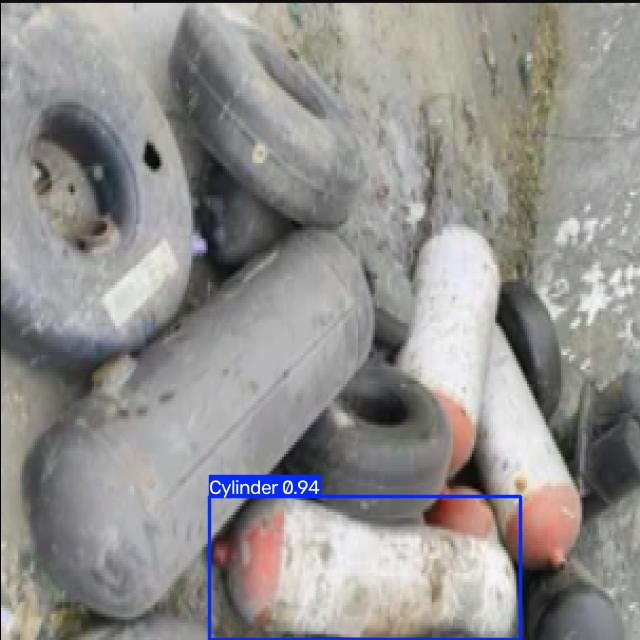

Prediction image: v2_train_00096.jpg


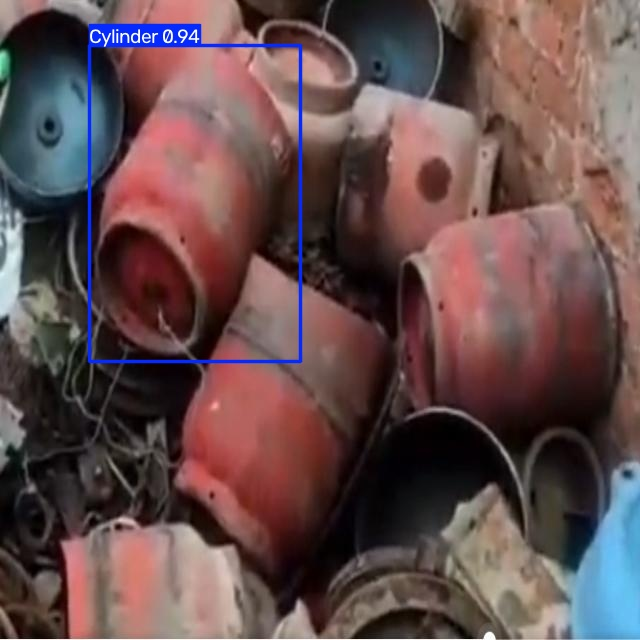

Prediction image: v2_train_00060.jpg


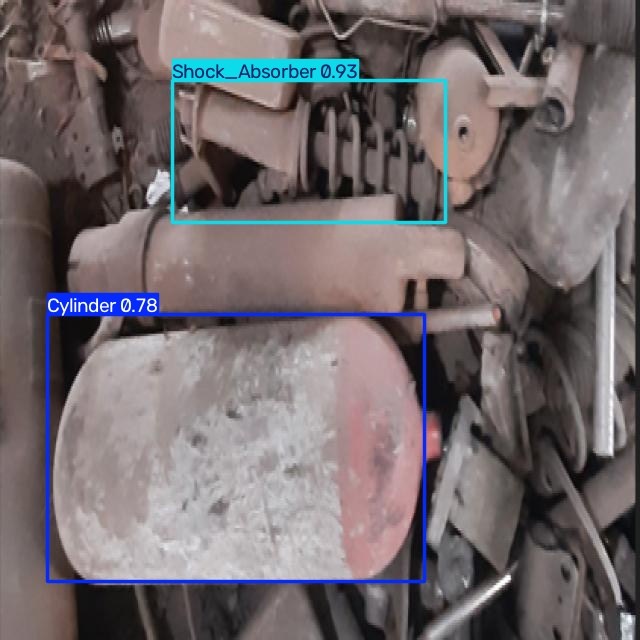

Prediction image: v1_train_00076.jpg


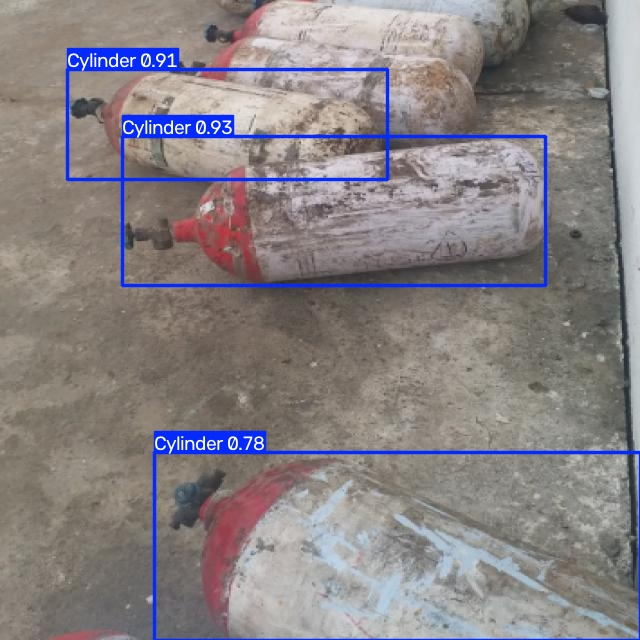

Prediction image: v1_train_00090.jpg


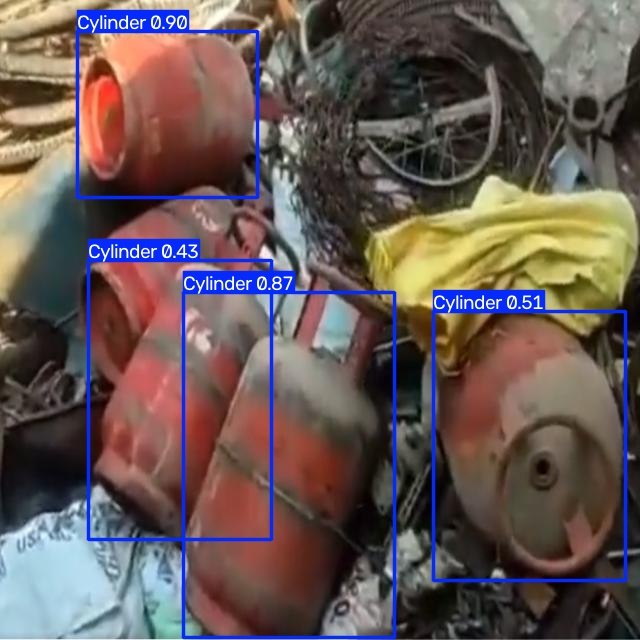

Prediction image: v2_train_00166.jpg


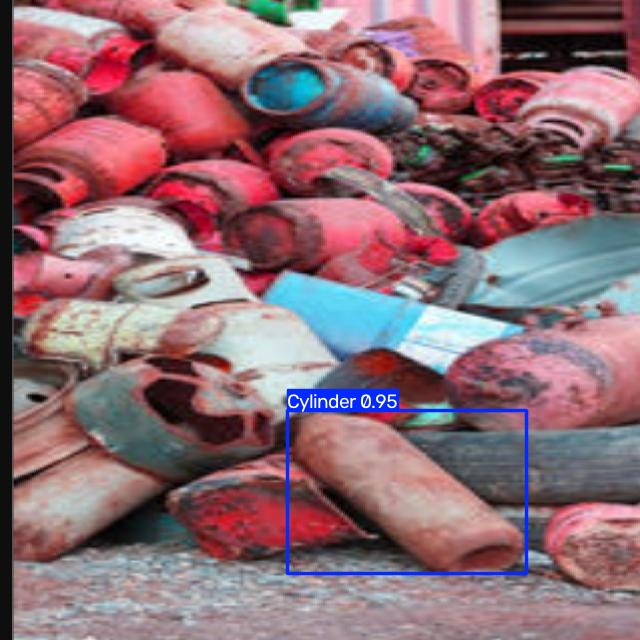

Prediction image: v1_train_00102.jpg


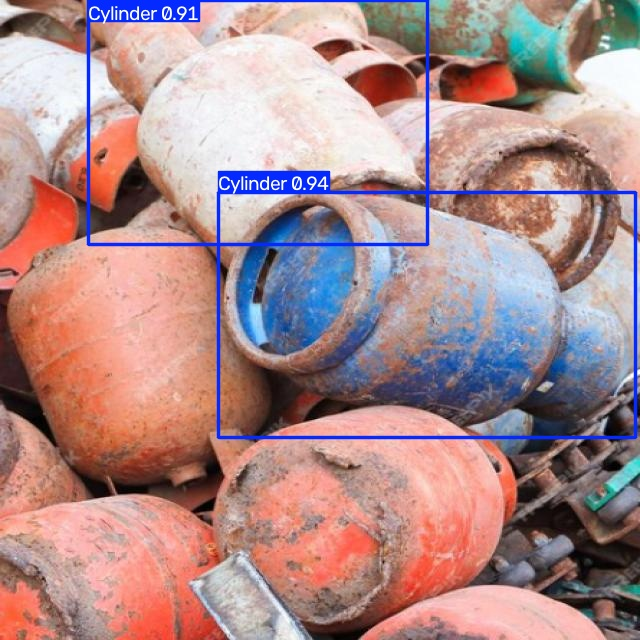

Prediction image: v2_train_00009.jpg


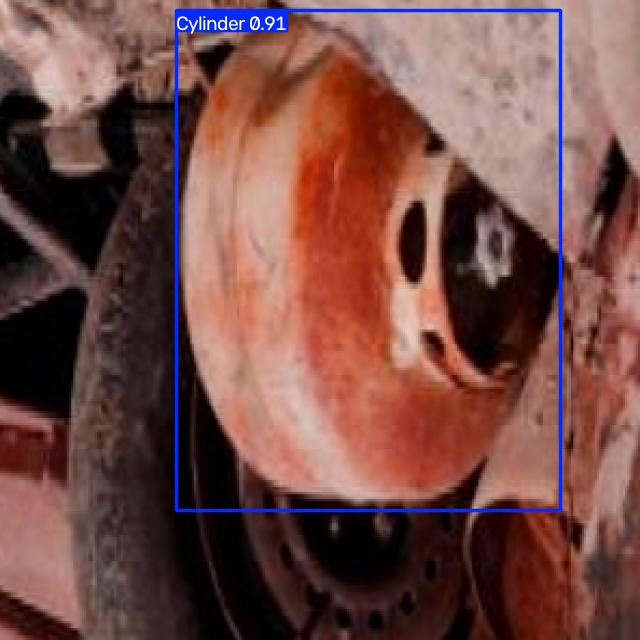

Prediction image: v1_train_00081.jpg


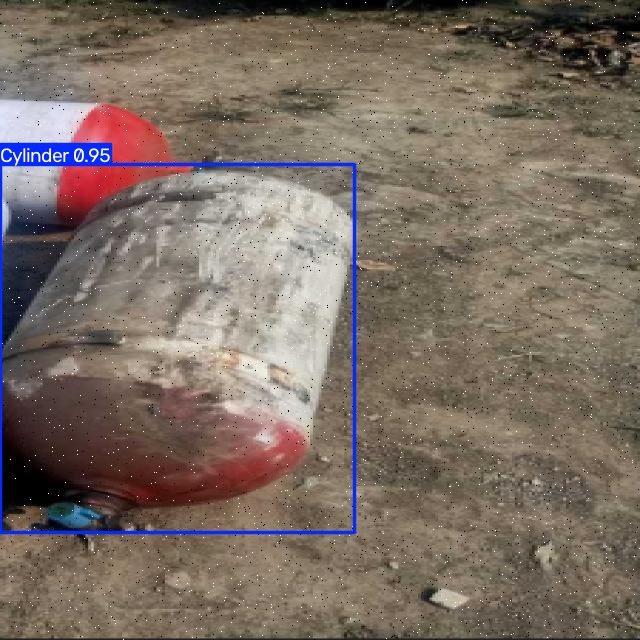

Prediction image: v1_train_00106.jpg


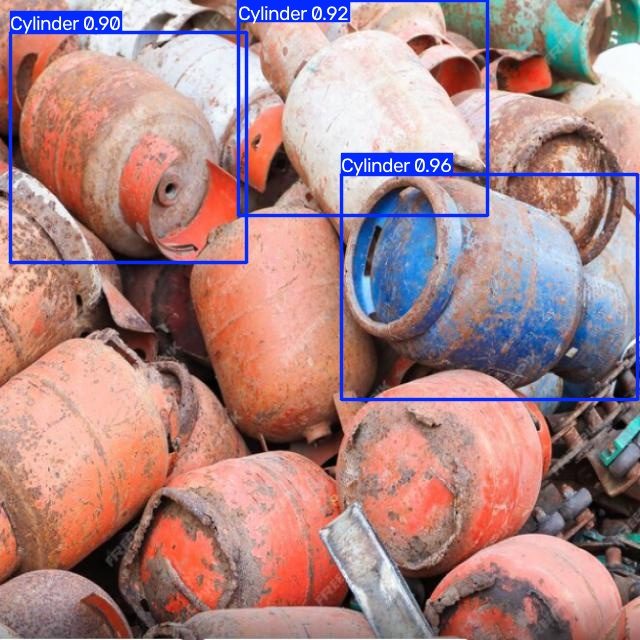


NO-DETECTION / LOW-DETECTION CHECK
Images with zero detections: 0

INFERENCE PIPELINE FINISHED
Saved annotated predictions at: c:\HAZ\runs\hazwaste_detection_inference\test_predictions


In [8]:
# ============================================================
# HAZARDOUS WASTE DETECTION - TEST INFERENCE + VISUALIZATION
# ============================================================

from ultralytics import YOLO
from pathlib import Path
from IPython.display import Image, display
import random

# ============================================================
# CONFIG
# ============================================================
BASE_DIR = Path.cwd()

BEST_MODEL = BASE_DIR / "runs" / "hazwaste_detection" / "yolov8n_baseline" / "weights" / "best.pt"
TEST_IMAGES_DIR = BASE_DIR / "datasets" / "final_dataset_detection" / "test" / "images"

INFER_PROJECT_DIR = BASE_DIR / "runs" / "hazwaste_detection_inference"
INFER_RUN_NAME = "test_predictions"

IMG_SIZE = 640
CONF_THRESHOLD = 0.25
MAX_IMAGES_TO_DISPLAY = 10   # notebook preview count

print("=" * 90)
print("INFERENCE CONFIG")
print("=" * 90)
print("BEST_MODEL       :", BEST_MODEL)
print("TEST_IMAGES_DIR  :", TEST_IMAGES_DIR)
print("INFER_PROJECT_DIR:", INFER_PROJECT_DIR)
print("CONF_THRESHOLD   :", CONF_THRESHOLD)

if not BEST_MODEL.exists():
    raise FileNotFoundError(f"best.pt not found: {BEST_MODEL}")

if not TEST_IMAGES_DIR.exists():
    raise FileNotFoundError(f"Test images folder not found: {TEST_IMAGES_DIR}")

# ============================================================
# LOAD MODEL
# ============================================================
model = YOLO(str(BEST_MODEL))

# ============================================================
# RUN INFERENCE ON FULL TEST SET
# ============================================================
results = model.predict(
    source=str(TEST_IMAGES_DIR),
    imgsz=IMG_SIZE,
    conf=CONF_THRESHOLD,
    save=True,
    project=str(INFER_PROJECT_DIR),
    name=INFER_RUN_NAME,
    exist_ok=True,
    verbose=True
)

print("\nInference completed.")

# Ultralytics saves annotated images here:
pred_dir = INFER_PROJECT_DIR / INFER_RUN_NAME
print("Prediction output folder:", pred_dir)

if not pred_dir.exists():
    raise FileNotFoundError(f"Prediction output folder not found: {pred_dir}")

# ============================================================
# SHOW PREDICTION SUMMARY PER IMAGE
# ============================================================
print("\n" + "=" * 90)
print("PREDICTION SUMMARY")
print("=" * 90)

for i, r in enumerate(results[:10]):  # show first 10 result summaries
    image_name = Path(r.path).name if hasattr(r, "path") else f"image_{i}"
    num_boxes = len(r.boxes) if r.boxes is not None else 0
    print(f"{i+1}. {image_name} -> detected boxes: {num_boxes}")

# ============================================================
# DISPLAY A RANDOM SAMPLE OF SAVED PREDICTION IMAGES
# ============================================================
pred_images = sorted([
    p for p in pred_dir.glob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

print("\nTotal saved prediction images:", len(pred_images))

if len(pred_images) == 0:
    print("No prediction images found.")
else:
    sample_count = min(MAX_IMAGES_TO_DISPLAY, len(pred_images))
    sample_images = random.sample(pred_images, sample_count)

    print(f"\nDisplaying {sample_count} random prediction images:\n")
    for img_path in sample_images:
        print(f"Prediction image: {img_path.name}")
        display(Image(filename=str(img_path)))

# ============================================================
# OPTIONAL: SHOW LOW-CONFIDENCE / NO-DETECTION CASES
# ============================================================
print("\n" + "=" * 90)
print("NO-DETECTION / LOW-DETECTION CHECK")
print("=" * 90)

no_detection_images = []

for r in results:
    image_name = Path(r.path).name if hasattr(r, "path") else "unknown"
    num_boxes = len(r.boxes) if r.boxes is not None else 0
    if num_boxes == 0:
        no_detection_images.append(image_name)

print("Images with zero detections:", len(no_detection_images))
if len(no_detection_images) > 0:
    for name in no_detection_images[:20]:
        print("-", name)

print("\n" + "=" * 90)
print("INFERENCE PIPELINE FINISHED")
print("=" * 90)
print("Saved annotated predictions at:", pred_dir)